# Instalação das bibliotecas

In [13]:
!pip install numpy pandas matplotlib plotly seaborn scipy statsmodels

# Importando as bibliotecas

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# Criando dados de exemplo

In [15]:
np.random.seed(42)
data = {
    'idade_equipamento': np.random.normal(10, 3, 100),
    'horas_parada': np.random.normal(18, 5, 100),
    'custo_manutencao': np.random.normal(25000, 6000, 100)
}

# Demonstração Pandas - Criação e manipulação básica de DataFrame

In [16]:
df = pd.DataFrame(data)
print("=== Demonstração Pandas ===")
print("Primeiras linhas do DataFrame:")
print(df.head())
print("\nEstatísticas descritivas:")
print(df.describe())

=== Demonstração Pandas ===
Primeiras linhas do DataFrame:
   idade_equipamento  horas_parada  custo_manutencao
0          11.490142     10.923146      27146.724162
1           9.585207     15.896773      28364.707158
2          11.943066     16.286427      31498.307459
3          14.569090     13.988614      31322.812312
4           9.297540     17.193571      16733.983792

Estatísticas descritivas:
       idade_equipamento  horas_parada  custo_manutencao
count         100.000000    100.000000        100.000000
mean            9.688460     18.111523      25389.377519
std             2.724505      4.768345       6505.697294
min             2.140765      8.406144       5552.395960
25%             8.197283     13.971697      21067.338756
50%             9.619131     18.420536      25586.174454
75%            11.217856     20.690852      29226.624687
max            15.556835     31.600846      48116.388944


# Demonstração Matplotlib - Gráfico básico

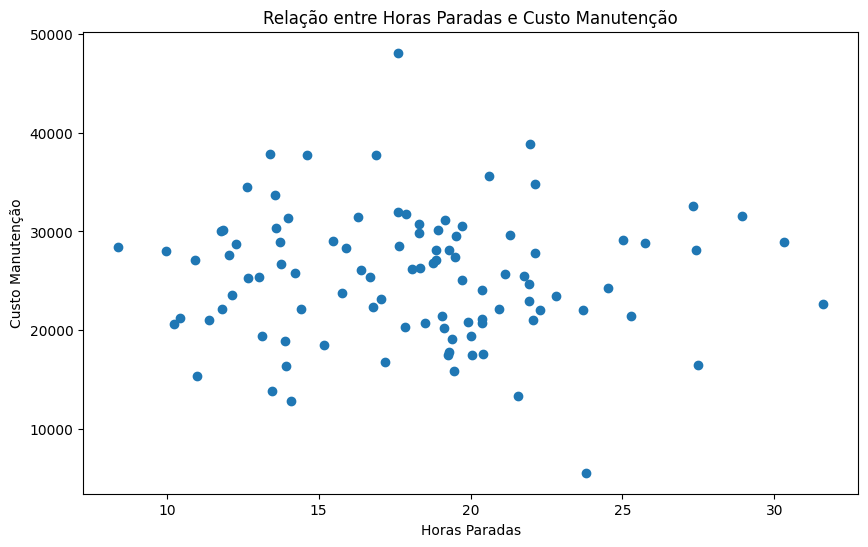

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(df['horas_parada'], df['custo_manutencao'])
plt.xlabel('Horas Paradas')
plt.ylabel('Custo Manutenção')
plt.title('Relação entre Horas Paradas e Custo Manutenção')
plt.show()

# Demonstração Seaborn - Visualização estatística

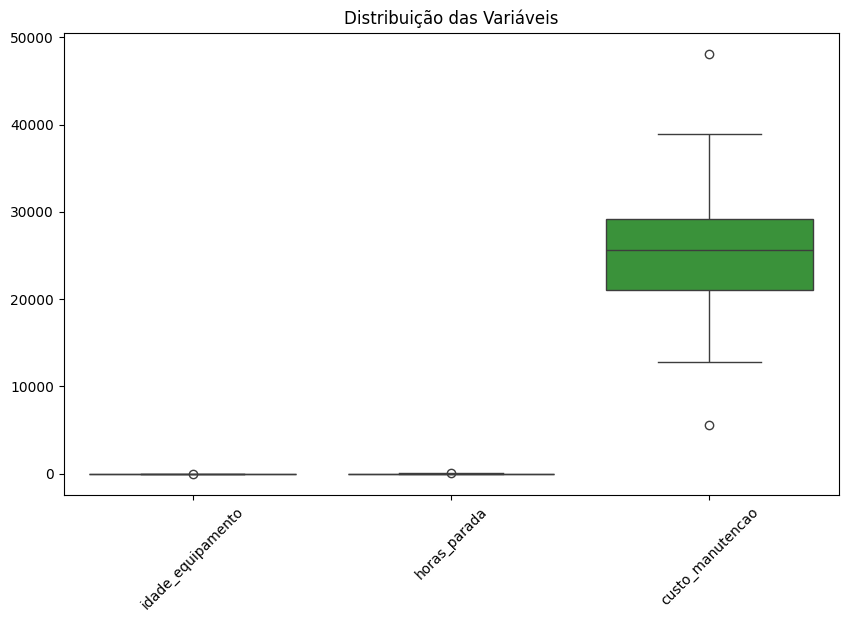

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title('Distribuição das Variáveis')
plt.xticks(rotation=45)
plt.show()

# Boxplot excluindo custo manutenção

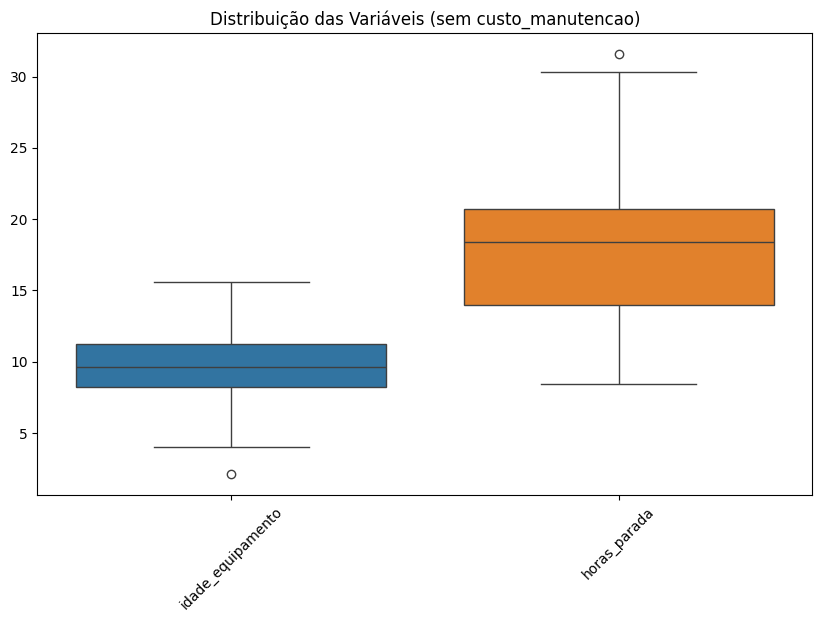

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['idade_equipamento', 'horas_parada']])
plt.title('Distribuição das Variáveis (sem custo_manutencao)')
plt.xticks(rotation=45)
plt.show()

# Demonstração Plotly - Gráfico interativo

In [20]:
fig = px.scatter(df, x='idade_equipamento', y='horas_parada', color='custo_manutencao',
                 title='Relação entre Idade do Equipamento, Horas Paradas e Custo da Manutenção')
fig.show()

# Demonstração SciPy - Teste estatístico

In [21]:
correlation, p_value = stats.pearsonr(df['idade_equipamento'], df['custo_manutencao'])
print("\n=== Demonstração SciPy ===")
print(f"Correlação entre idade do equipamento e custo da manutenção: {correlation:.2f}")
print(f"P-valor: {p_value:.4f}")


=== Demonstração SciPy ===
Correlação entre idade do equipamento e custo da manutenção: 0.19
P-valor: 0.0572


# Demonstração Statsmodels - Regressão linear

In [22]:
X = sm.add_constant(df['idade_equipamento'])
model = sm.OLS(df['custo_manutencao'], X).fit()
print("\n=== Demonstração Statsmodels ===")
print("Resumo da Regressão Linear:")
print(model.summary().tables[1])


=== Demonstração Statsmodels ===
Resumo da Regressão Linear:
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              2.097e+04   2382.097      8.805      0.000    1.62e+04    2.57e+04
idade_equipamento   455.6962    236.776      1.925      0.057     -14.177     925.570


# Visualização da reta de regressão

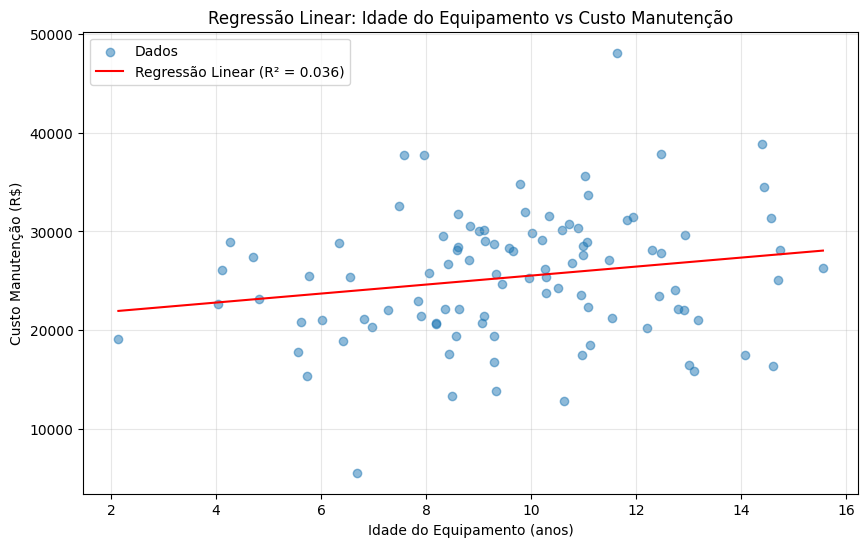

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(df['idade_equipamento'], df['custo_manutencao'], alpha=0.5, label='Dados')
x_range = np.linspace(df['idade_equipamento'].min(), df['idade_equipamento'].max(), 100)
X_plot = sm.add_constant(x_range)
y_pred = model.predict(X_plot)
plt.plot(x_range, y_pred, 'r', label=f'Regressão Linear (R² = {model.rsquared:.3f})')
plt.xlabel('Idade do Equipamento (anos)')
plt.ylabel('Custo Manutenção (R$)')
plt.title('Regressão Linear: Idade do Equipamento vs Custo Manutenção')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()